# QRT data at a glance

### The empirical facts that determine the validation design

This notebook describes the supplied data before any model comparison. It
focuses on five questions:

1. Is the panel structurally sound and sufficiently covered?
2. Where are values missing, and how heterogeneous is the target?
3. What dependence is present in the 20 supplied lags?
4. Which variables contain the clearest elementary signal?
5. How different are the train and test distributions?

The objective is not to prove that a feature is useful. It is to identify the
constraints that every subsequent experiment must respect.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wasserstein_distance

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import ChallengeDataLoader

train = ChallengeDataLoader.load_train_df()
test = ChallengeDataLoader.load_X_test()
X_train = train.drop(columns=["target", "target_binarized"])

RETURNS = [f"RET_{lag}" for lag in range(1, 21)]
VOLUMES = [f"SIGNED_VOLUME_{lag}" for lag in range(1, 21)]
RAW_FEATURES = RETURNS + VOLUMES + ["MEDIAN_DAILY_TURNOVER"]

COLORS = {
    "ink": "#183446",
    "train": "#264653",
    "test": "#2A9D8F",
    "accent": "#E76F51",
    "gold": "#E9C46A",
    "muted": "#8A99A6",
    "light": "#EEF3F5",
    "grid": "#DCE4E8",
}

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.05,
    rc={
        "axes.edgecolor": COLORS["grid"],
        "axes.labelcolor": COLORS["ink"],
        "axes.titlecolor": COLORS["ink"],
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.65,
        "xtick.color": COLORS["ink"],
        "ytick.color": COLORS["ink"],
    },
)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)


def clean_axis(ax, *, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, loc="left", pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["left"].set_color(COLORS["grid"])
    ax.spines["bottom"].set_color(COLORS["grid"])
    return ax


def temporal_summaries(frame):
    return pd.DataFrame(
        {
            "recent_return_mean": frame[["RET_1", "RET_2", "RET_3"]].mean(axis=1),
            "medium_return_mean": frame[[f"RET_{lag}" for lag in range(1, 11)]].mean(axis=1),
            "older_return_mean": frame[[f"RET_{lag}" for lag in range(11, 21)]].mean(axis=1),
            "recent_minus_older": (
                frame[["RET_1", "RET_2", "RET_3"]].mean(axis=1)
                - frame[[f"RET_{lag}" for lag in range(11, 21)]].mean(axis=1)
            ),
            "short_return_volatility": frame[[f"RET_{lag}" for lag in range(1, 6)]].std(axis=1),
            "one_step_reversal": (
                frame["RET_1"]
                - frame[["RET_2", "RET_3", "RET_4", "RET_5"]].mean(axis=1)
            ),
            "positive_return_share": (frame[RETURNS] > 0).mean(axis=1),
        },
        index=frame.index,
    )


train_temporal = temporal_summaries(train)
test_temporal = temporal_summaries(test)

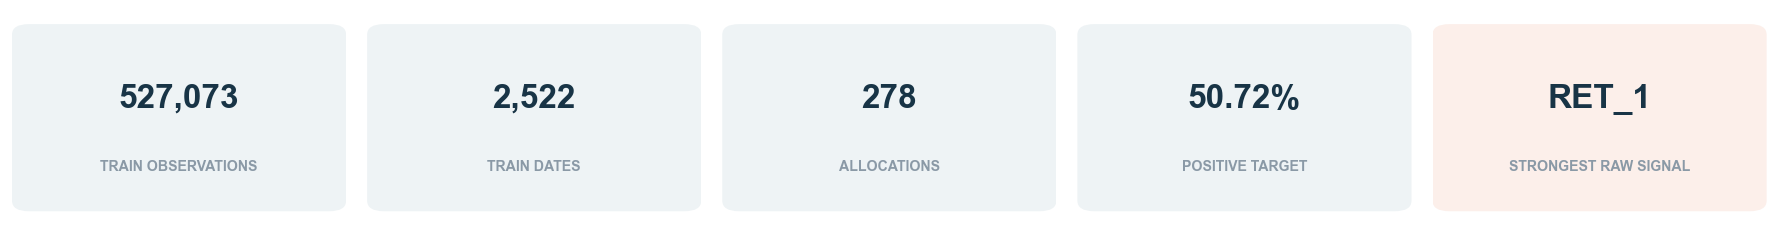

In [2]:

headline_metrics = [
    (f"{len(train):,}", "TRAIN OBSERVATIONS"),
    (f"{train['TS'].nunique():,}", "TRAIN DATES"),
    (f"{train['ALLOCATION'].nunique():,}", "ALLOCATIONS"),
    (f"{train['target_binarized'].mean():.2%}", "POSITIVE TARGET"),
    ("RET_1", "STRONGEST RAW SIGNAL"),
]

fig, axes = plt.subplots(1, len(headline_metrics), figsize=(15, 2.15))
for position, (ax, (value, label)) in enumerate(zip(axes, headline_metrics)):
    ax.set_axis_off()
    card_color = COLORS["light"] if position < 4 else "#FCEFEA"
    card = FancyBboxPatch(
        (0.02, 0.08), 0.96, 0.84,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        transform=ax.transAxes,
        facecolor=card_color,
        edgecolor="none",
    )
    ax.add_patch(card)
    ax.text(0.5, 0.59, value, ha="center", va="center", fontsize=20,
            fontweight="bold", color=COLORS["ink"], transform=ax.transAxes)
    ax.text(0.5, 0.27, label, ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=COLORS["muted"], transform=ax.transAxes)
plt.tight_layout(w_pad=1.0)
plt.show()


## 1. Data integrity and panel coverage

The checklist verifies the basic data contract. The coverage curves then sort
dates and allocations from least to most represented:

- the left panel shows the share of allocations observed on each date;
- the right panel shows the share of dates observed for each allocation.

This ranked representation preserves the discrete structure of the panel and
does not depend on histogram bins.

In [3]:
train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(test, index=False)

checks = [
    ("Unique train row identifiers", train.index.is_unique, f"{len(train):,} rows"),
    ("Unique test row identifiers", test.index.is_unique, f"{len(test):,} rows"),
    ("Matching train/test feature schema", set(X_train.columns) == set(test.columns), f"{test.shape[1]} features"),
    ("No duplicated train feature rows", X_train.duplicated().sum() == 0, f"{X_train.duplicated().sum():,} duplicates"),
    ("No duplicated test feature rows", test.duplicated().sum() == 0, f"{test.duplicated().sum():,} duplicates"),
    (
        "No exact feature rows shared across train and test",
        len(set(train_hash.unique()) & set(test_hash.unique())) == 0,
        f"{len(set(train_hash.unique()) & set(test_hash.unique())):,} shared rows",
    ),
    (
        "No infinite numeric values",
        np.isinf(train.select_dtypes(include=np.number)).sum().sum() == 0,
        f"{np.isinf(train.select_dtypes(include=np.number)).sum().sum():,} values",
    ),
    ("No constant train features", (X_train.nunique(dropna=False) <= 1).sum() == 0, f"{(X_train.nunique(dropna=False) <= 1).sum()} constant features"),
    (
        "All test allocations are represented in train",
        set(test["ALLOCATION"]).issubset(set(train["ALLOCATION"])),
        f"{len(set(test['ALLOCATION']) - set(train['ALLOCATION']))} unseen levels",
    ),
    (
        "All test groups are represented in train",
        set(test["GROUP"]).issubset(set(train["GROUP"])),
        f"{len(set(test['GROUP']) - set(train['GROUP']))} unseen levels",
    ),
]
integrity_checks = pd.DataFrame(checks, columns=["check", "passed", "detail"])
integrity_checks["status"] = np.where(integrity_checks["passed"], "PASS", "REVIEW")
(
    integrity_checks[["status", "check", "detail"]]
    .style.hide(axis="index")
    .set_caption("Data integrity checklist")
    .map(
        lambda value: (
            "color: #1F6F5C; background-color: #E8F5F0; font-weight: bold"
            if value == "PASS"
            else "color: #9C3D2C; background-color: #FCEFEA; font-weight: bold"
        ),
        subset=["status"],
    )
    .set_properties(**{"text-align": "left"})
)

status,check,detail
PASS,Unique train row identifiers,"527,073 rows"
PASS,Unique test row identifiers,"31,870 rows"
PASS,Matching train/test feature schema,44 features
PASS,No duplicated train feature rows,0 duplicates
PASS,No duplicated test feature rows,0 duplicates
PASS,No exact feature rows shared across train and test,0 shared rows
PASS,No infinite numeric values,0 values
PASS,No constant train features,0 constant features
PASS,All test allocations are represented in train,0 unseen levels
PASS,All test groups are represented in train,0 unseen levels


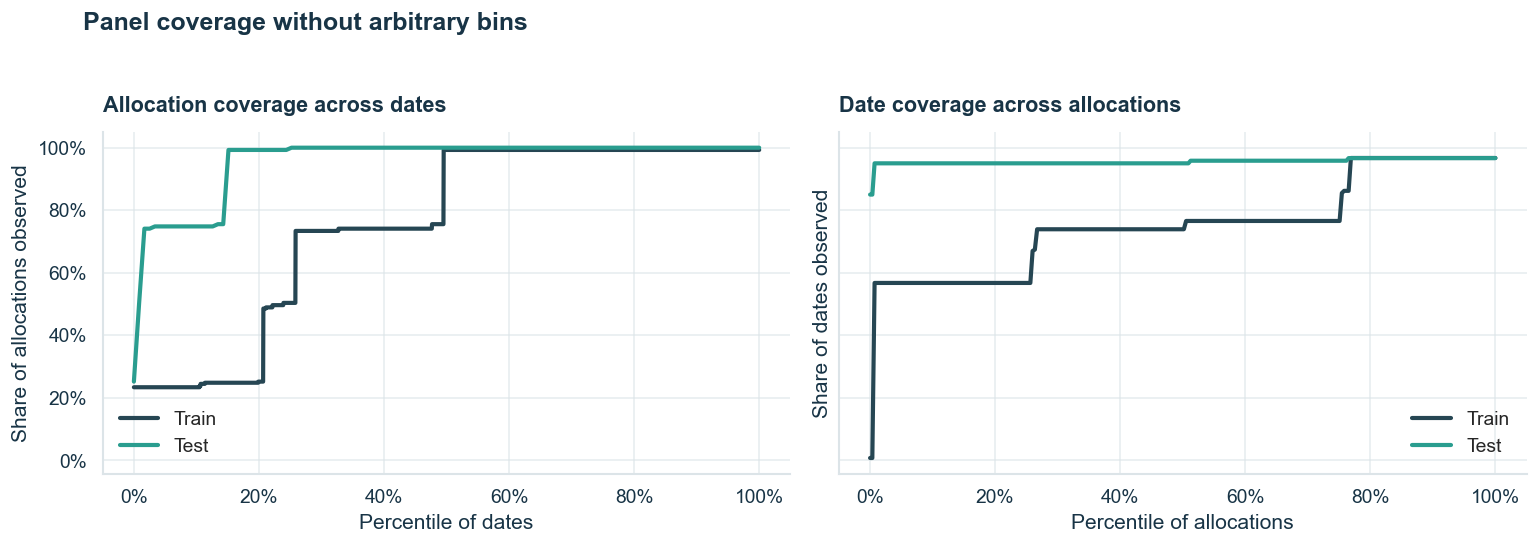

In [4]:
def ranked_coverage(values):
    """Return sorted coverage values against the entity percentile."""
    ordered = np.sort(np.asarray(values))
    percentile = np.linspace(0, 1, len(ordered))
    return percentile, ordered


date_coverage = {
    "Train": train.groupby("TS")["ALLOCATION"].nunique() / train["ALLOCATION"].nunique(),
    "Test": test.groupby("TS")["ALLOCATION"].nunique() / test["ALLOCATION"].nunique(),
}
allocation_coverage = {
    "Train": train.groupby("ALLOCATION")["TS"].nunique() / train["TS"].nunique(),
    "Test": test.groupby("ALLOCATION")["TS"].nunique() / test["TS"].nunique(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for label, values in date_coverage.items():
    x, y = ranked_coverage(values)
    color = COLORS["train"] if label == "Train" else COLORS["test"]
    axes[0].plot(x, y, color=color, linewidth=2.5, label=label)
axes[0].legend(frameon=False)
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(
    axes[0],
    title="Allocation coverage across dates",
    xlabel="Percentile of dates",
    ylabel="Share of allocations observed",
)

for label, values in allocation_coverage.items():
    x, y = ranked_coverage(values)
    color = COLORS["train"] if label == "Train" else COLORS["test"]
    axes[1].plot(x, y, color=color, linewidth=2.5, label=label)
axes[1].legend(frameon=False)
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(
    axes[1],
    title="Date coverage across allocations",
    xlabel="Percentile of allocations",
    ylabel="Share of dates observed",
)

fig.suptitle(
    "Panel coverage without arbitrary bins",
    x=0.06,
    y=1.03,
    ha="left",
    fontsize=15,
    fontweight="bold",
    color=COLORS["ink"],
)
plt.tight_layout()
plt.show()

> **What the plots show.** The data contract is clean: identifiers are unique,
> feature schemas match, no exact observations are shared, and every test
> allocation and group is already represented in train. Coverage is less
> uniform. Half of train dates contain about 99% of allocations, but the least
> covered dates contain only 23%. Half of allocations appear on 74% of train
> dates, with a small number observed very rarely. Test coverage is much more
> homogeneous.
>
> **Decision.** Validation must keep complete `TS` groups together. Allocation
> effects require shrinkage, because their effective sample sizes differ
> substantially.

## 2. Missingness and target heterogeneity

The heatmap displays missing-value rates for all 20 return and signed-volume
lags in both datasets. The stacked bars provide the complementary row-level
view: they show how many signed-volume values are missing within an individual
observation.

The following figure compares target prevalence across dates, allocations and
broad groups. These are descriptive distributions, not uncertainty estimates.

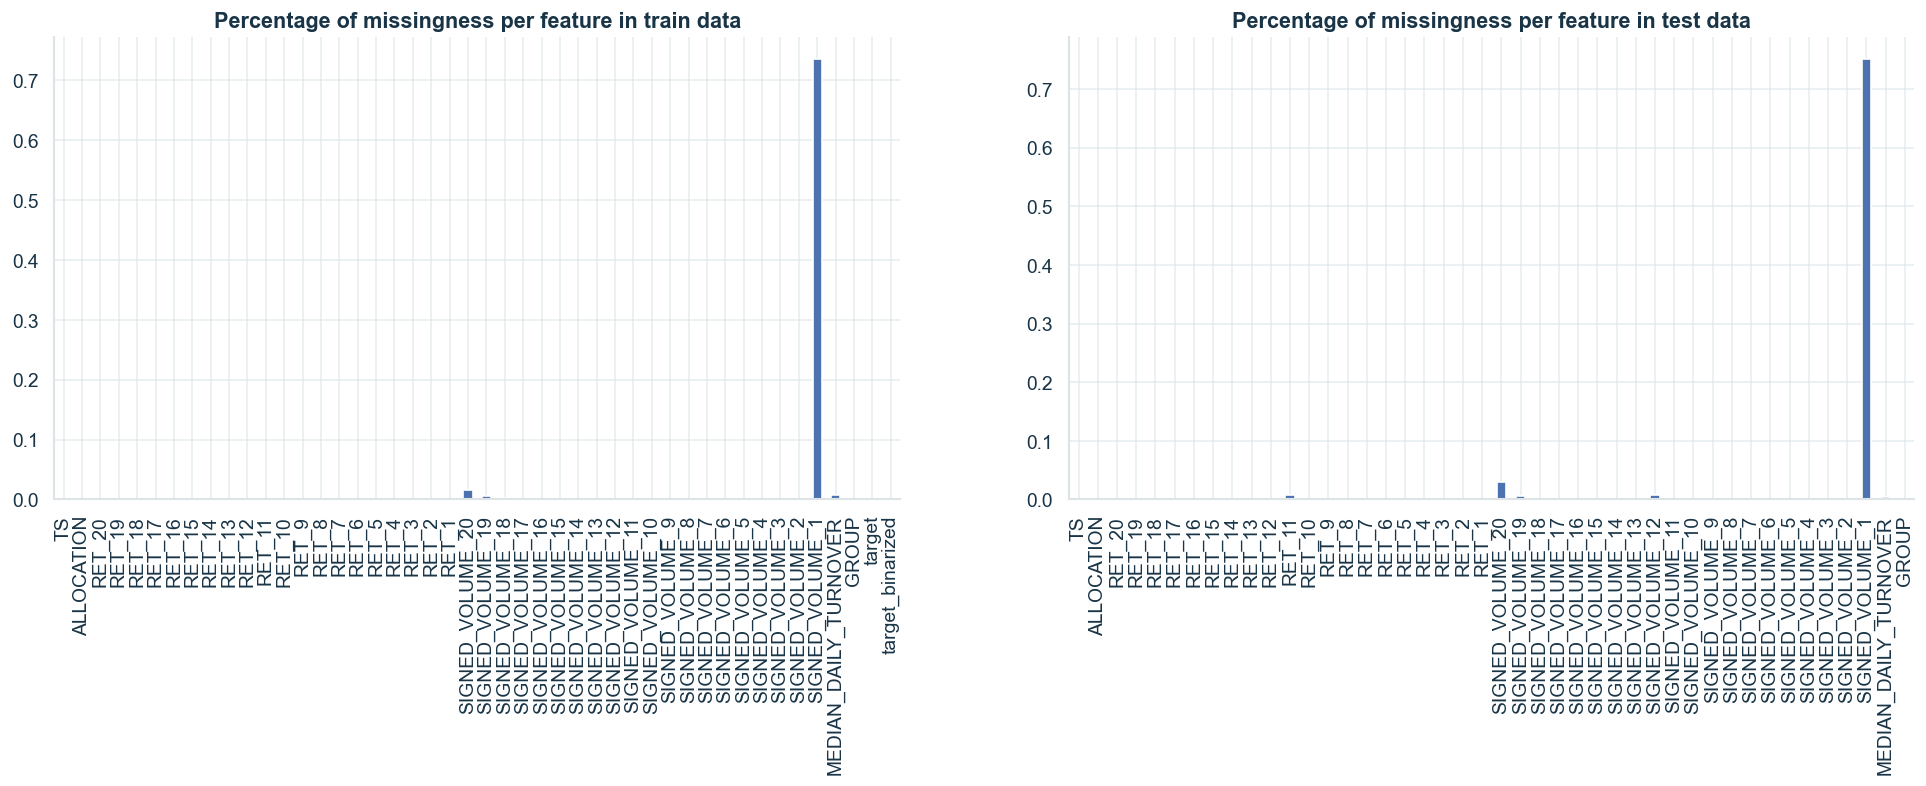

In [5]:
_, ax = plt.subplots(1,2, figsize=(20, 5))
ax[0].set_title("Percentage of missingness per feature in train data")
ax[1].set_title("Percentage of missingness per feature in test data")
train.isna().mean().plot(kind="bar", ax=ax[0])
test.isna().mean().plot(kind="bar", ax=ax[1])
plt.show()

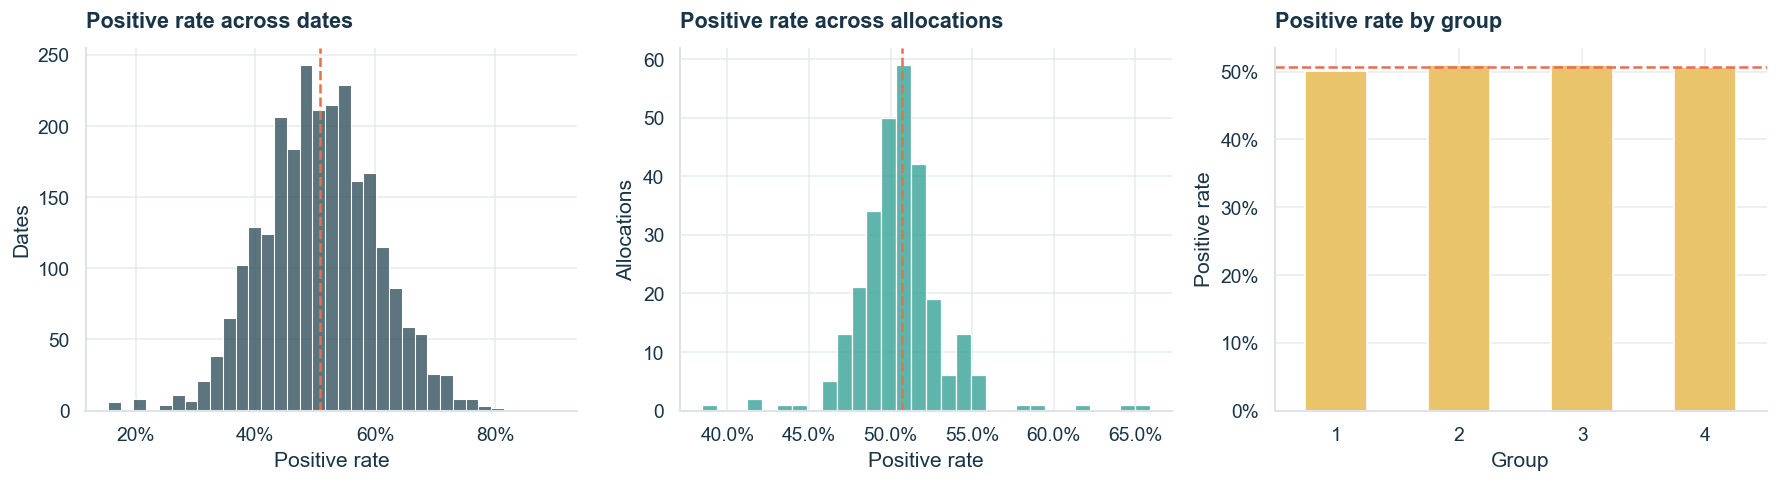

,dates,allocations
quantile,,
0.100000,38.77%,48.01%
0.250000,44.20%,49.25%
0.500000,50.72%,50.49%
0.750000,56.88%,51.64%
0.900000,63.02%,53.32%


In [6]:
overall_positive_rate = train["target_binarized"].mean()
target_by = {
    level: train.groupby(level)["target_binarized"].mean()
    for level in ["TS", "ALLOCATION", "GROUP"]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(target_by["TS"], bins=35, color=COLORS["train"], ax=axes[0])
axes[0].axvline(overall_positive_rate, color=COLORS["accent"], linestyle="--")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(axes[0], title="Positive rate across dates", xlabel="Positive rate", ylabel="Dates")

sns.histplot(target_by["ALLOCATION"], bins=30, color=COLORS["test"], ax=axes[1])
axes[1].axvline(overall_positive_rate, color=COLORS["accent"], linestyle="--")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(axes[1], title="Positive rate across allocations", xlabel="Positive rate", ylabel="Allocations")

target_by["GROUP"].sort_index().plot.bar(color=COLORS["gold"], ax=axes[2])
axes[2].axhline(overall_positive_rate, color=COLORS["accent"], linestyle="--")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].tick_params(axis="x", rotation=0)
clean_axis(axes[2], title="Positive rate by group", xlabel="Group", ylabel="Positive rate")
plt.tight_layout()
plt.show()

target_summary = pd.DataFrame(
    {
        "dates": target_by["TS"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]),
        "allocations": target_by["ALLOCATION"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]),
    }
).rename_axis("quantile")
target_summary.style.format("{:.2%}").set_caption("Target-rate heterogeneity")

> **What the plots show.** Returns are essentially complete. Missingness is
> concentrated in `SIGNED_VOLUME_1`: roughly three quarters of rows have one
> missing signed-volume value, while only about 3% have two or more. The pattern
> is similar in train and test. Target prevalence is much more dispersed across
> dates—the interquartile range is approximately 44% to 57%—than across
> allocations, where it is approximately 49% to 52%.
>
> **Decision.** Missing-value handling must be part of the fitted pipeline, and
> rows cannot be treated as independent sampling units.

## 3. Marginal distributions and short-lag dependence

`RET_1` and `SIGNED_VOLUME_1` are the most recent supplied values; lag 20 is
the oldest. The boxplots compare marginal distributions across this short
history. Outlier markers are hidden so that the central distributions remain
readable.

The correlation heatmaps then examine dependence between all supplied lags.
This is valid within-row lag analysis; it does not assume that the labels in
`TS` form an observed chronological calendar.

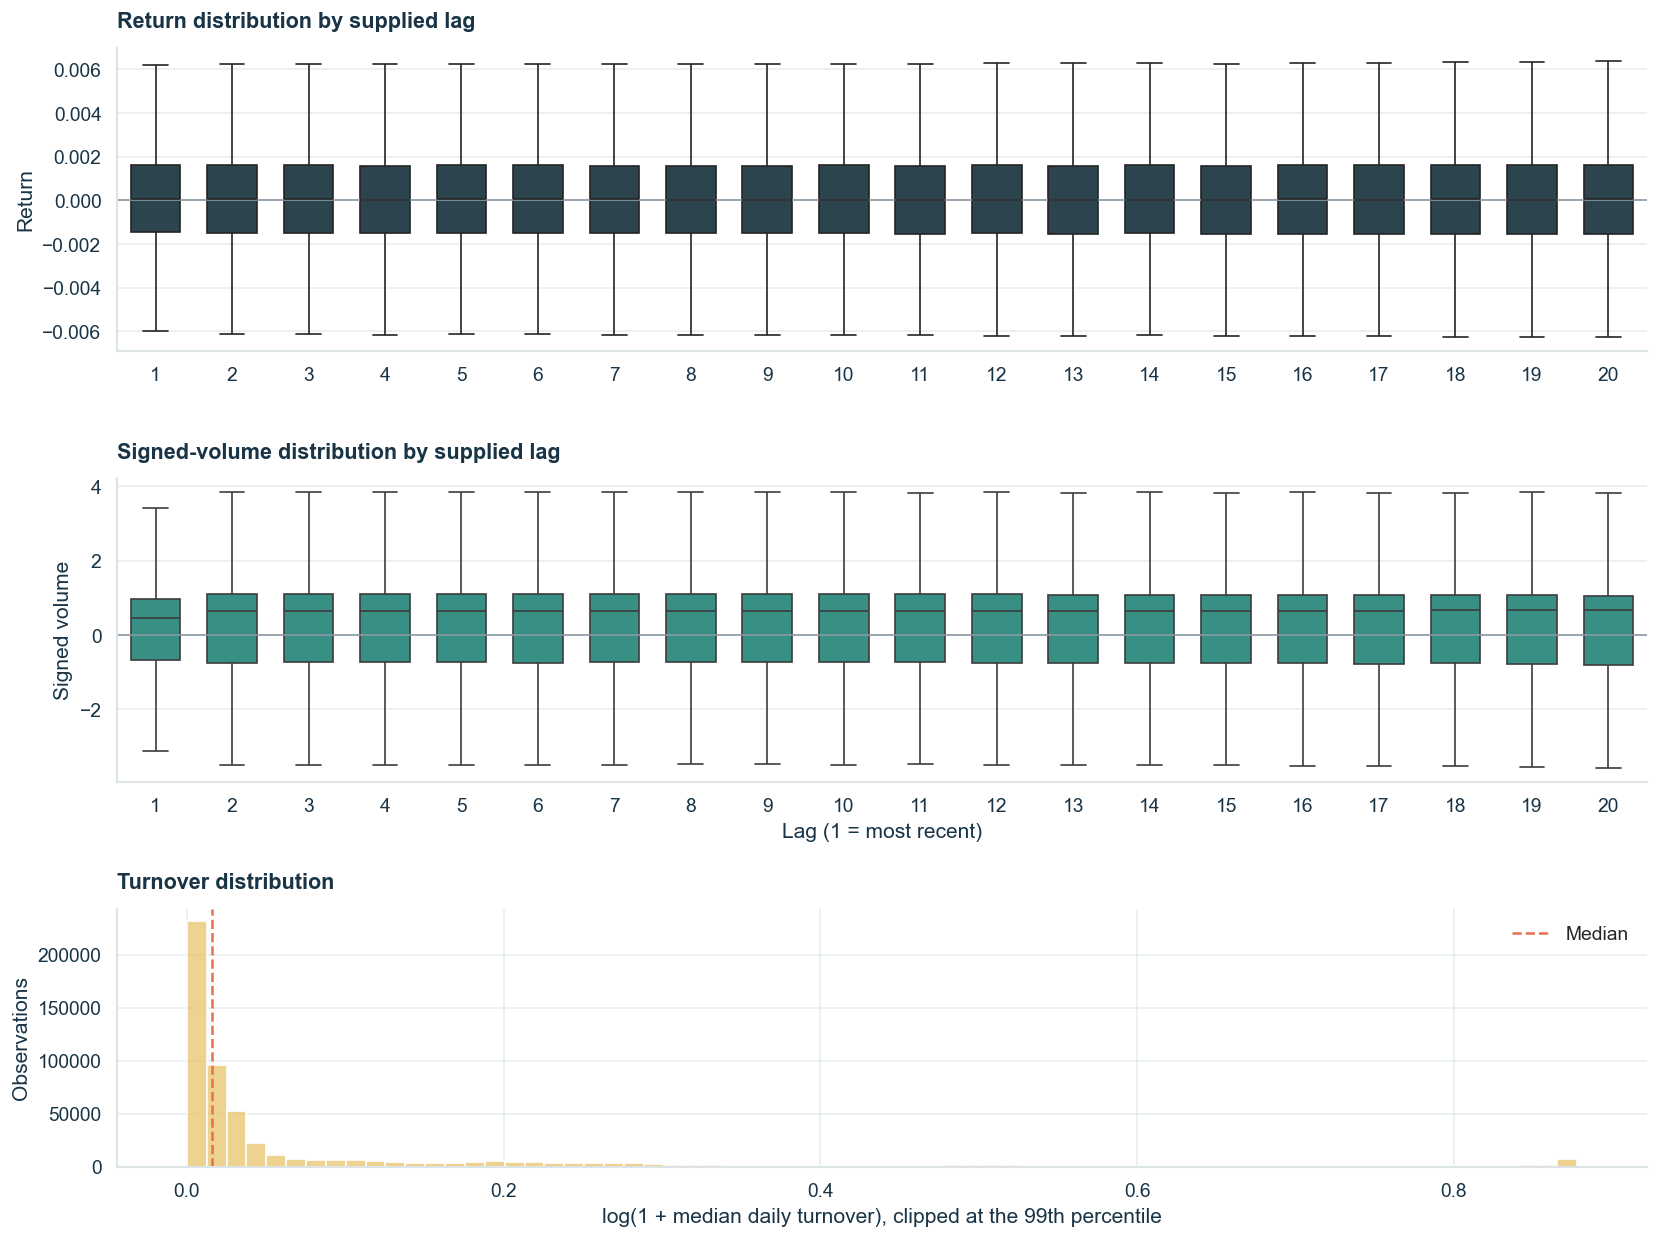

In [7]:
plot_sample = train.sample(n=min(100_000, len(train)), random_state=0)
return_long = plot_sample[RETURNS].rename(columns={name: int(name.split("_")[-1]) for name in RETURNS}).melt(
    var_name="lag", value_name="value"
)
volume_long = plot_sample[VOLUMES].rename(columns={name: int(name.split("_")[-1]) for name in VOLUMES}).melt(
    var_name="lag", value_name="value"
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10.5), gridspec_kw={"height_ratios": [1, 1, 0.85]})
sns.boxplot(
    data=return_long,
    x="lag",
    y="value",
    color=COLORS["train"],
    showfliers=False,
    width=0.65,
    ax=axes[0],
)
axes[0].axhline(0, color=COLORS["muted"], linewidth=1)
clean_axis(axes[0], title="Return distribution by supplied lag", xlabel="", ylabel="Return")

sns.boxplot(
    data=volume_long,
    x="lag",
    y="value",
    color=COLORS["test"],
    showfliers=False,
    width=0.65,
    ax=axes[1],
)
axes[1].axhline(0, color=COLORS["muted"], linewidth=1)
clean_axis(axes[1], title="Signed-volume distribution by supplied lag", xlabel="Lag (1 = most recent)", ylabel="Signed volume")

turnover_log = np.log1p(train["MEDIAN_DAILY_TURNOVER"].dropna())
sns.histplot(turnover_log.clip(upper=turnover_log.quantile(0.99)), bins=70, color=COLORS["gold"], ax=axes[2])
axes[2].axvline(turnover_log.median(), color=COLORS["accent"], linestyle="--", label="Median")
axes[2].legend(frameon=False)
clean_axis(
    axes[2],
    title="Turnover distribution",
    xlabel="log(1 + median daily turnover), clipped at the 99th percentile",
    ylabel="Observations",
)
plt.tight_layout(h_pad=1.5)
plt.show()

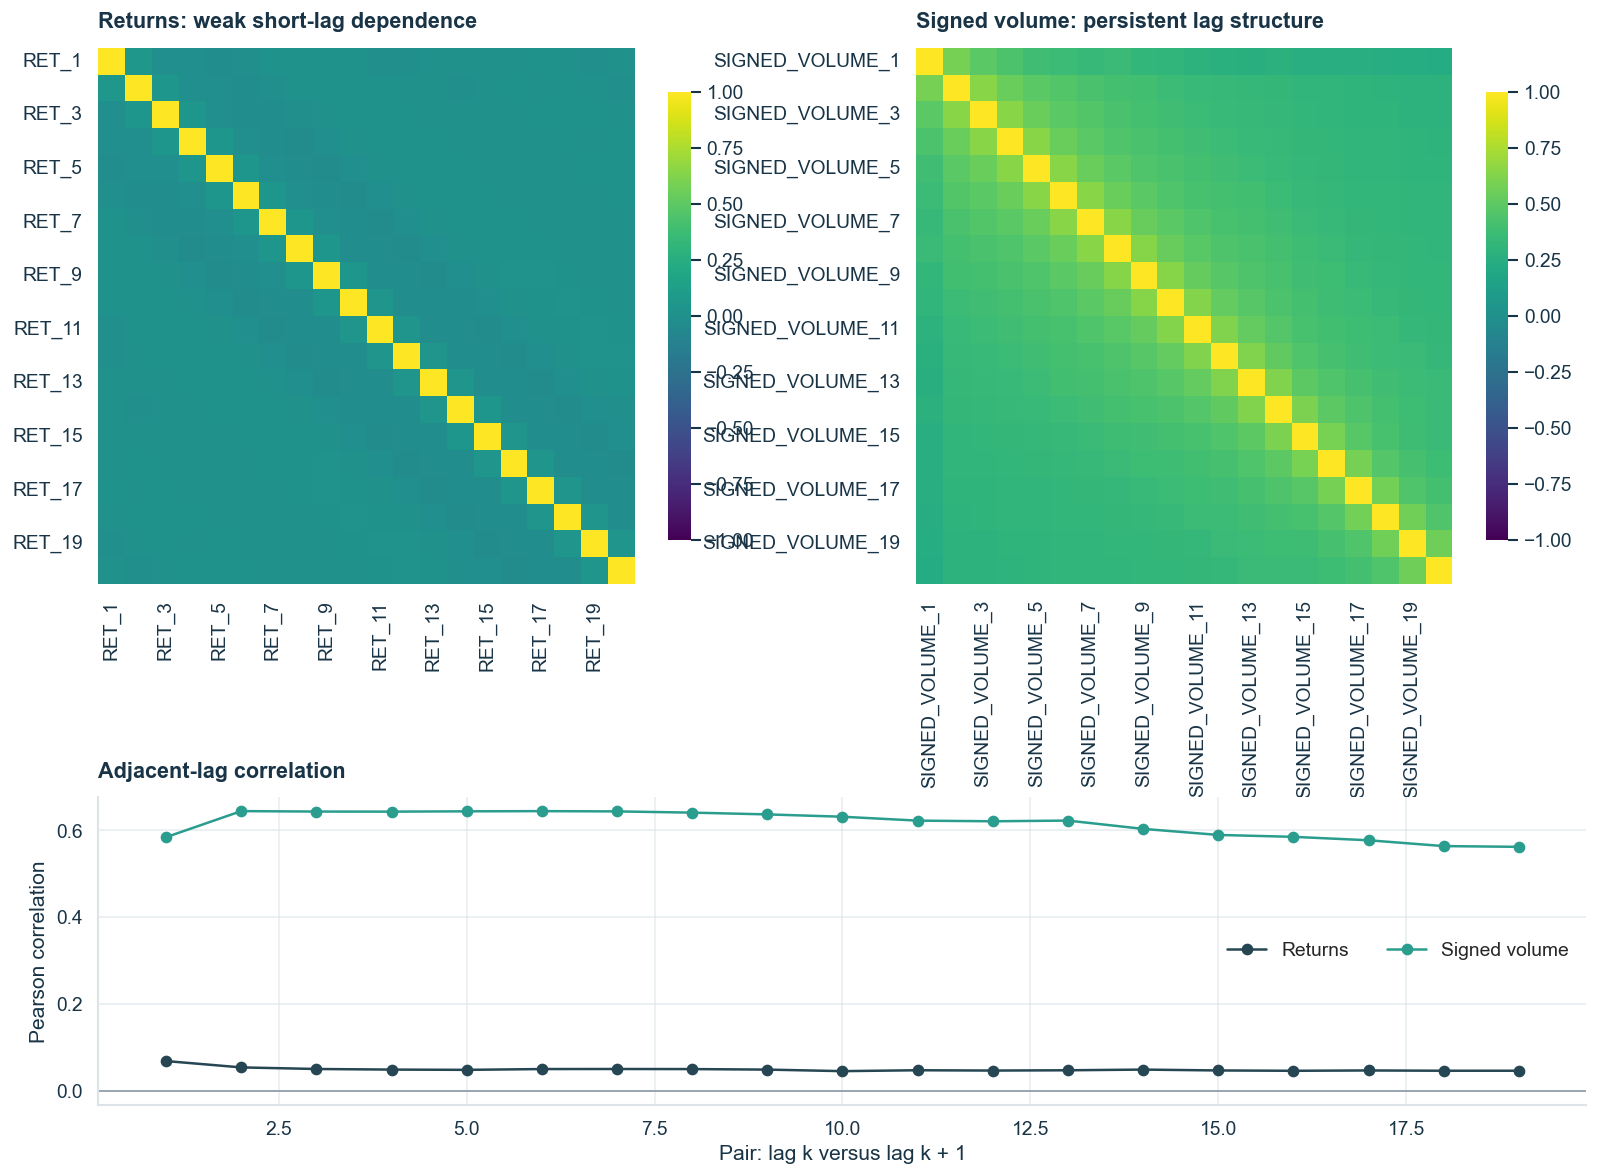

In [8]:
return_correlation = train[RETURNS].corr()
volume_correlation = train[VOLUMES].corr()
adjacent_dependence = pd.DataFrame(
    {
        "lag": range(1, 20),
        "returns": [train[f"RET_{lag}"].corr(train[f"RET_{lag + 1}"]) for lag in range(1, 20)],
        "signed volume": [train[f"SIGNED_VOLUME_{lag}"].corr(train[f"SIGNED_VOLUME_{lag + 1}"]) for lag in range(1, 20)],
    }
)

fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.48], hspace=0.34, wspace=0.22)
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[1, :])]

sns.heatmap(return_correlation, cmap="viridis", center=0, vmin=-1, vmax=1, square=True, xticklabels=2, yticklabels=2, cbar_kws={"shrink": 0.7}, ax=axes[0])
clean_axis(axes[0], title="Returns: weak short-lag dependence", xlabel="", ylabel="")
sns.heatmap(volume_correlation, cmap="viridis", vmin=-1, vmax=1, square=True, xticklabels=2, yticklabels=2, cbar_kws={"shrink": 0.7}, ax=axes[1])
clean_axis(axes[1], title="Signed volume: persistent lag structure", xlabel="", ylabel="")

axes[2].plot(adjacent_dependence["lag"], adjacent_dependence["returns"], color=COLORS["train"], marker="o", label="Returns")
axes[2].plot(adjacent_dependence["lag"], adjacent_dependence["signed volume"], color=COLORS["test"], marker="o", label="Signed volume")
axes[2].axhline(0, color=COLORS["muted"], linewidth=1)
axes[2].legend(frameon=False, ncol=2)
clean_axis(axes[2], title="Adjacent-lag correlation", xlabel="Pair: lag k versus lag k + 1", ylabel="Pearson correlation")
plt.show()

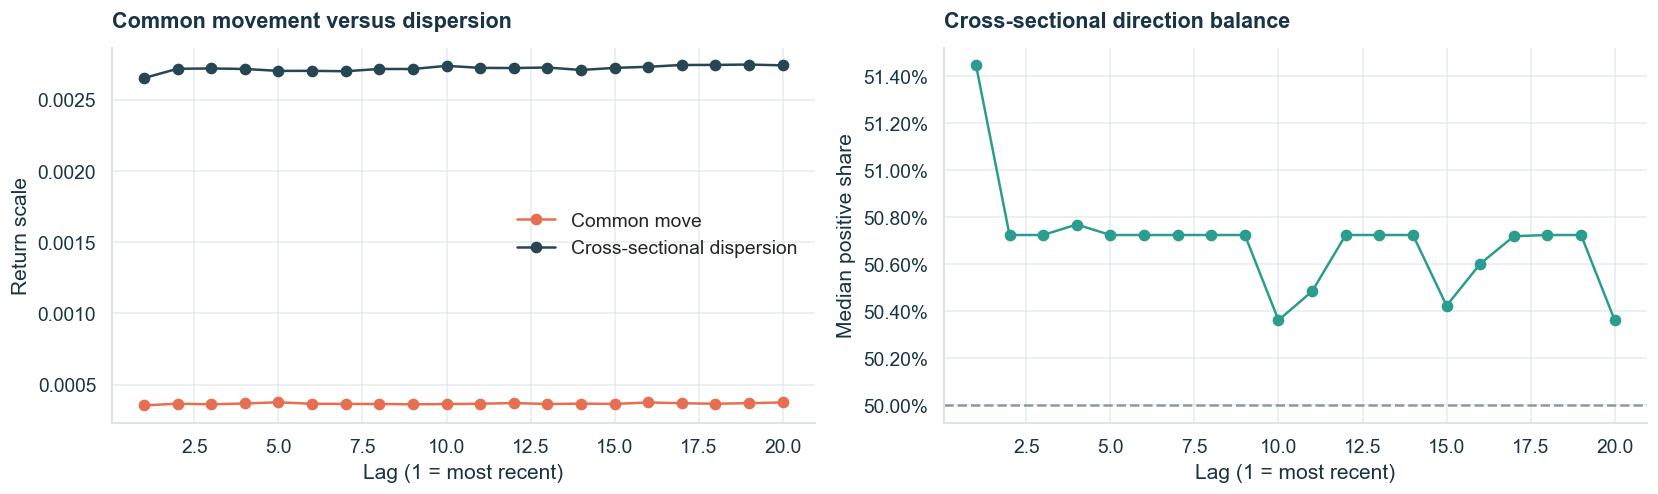

In [9]:
date_location = train.groupby("TS")[RETURNS].median()
date_dispersion = train.groupby("TS")[RETURNS].std()
cross_sectional_profile = pd.DataFrame(
    {
        "lag": range(1, 21),
        "common move": [date_location[f"RET_{lag}"].abs().median() for lag in range(1, 21)],
        "cross-sectional dispersion": [date_dispersion[f"RET_{lag}"].median() for lag in range(1, 21)],
        "positive share": [
            train.assign(positive=train[f"RET_{lag}"] > 0).groupby("TS")["positive"].mean().median()
            for lag in range(1, 21)
        ],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].plot(cross_sectional_profile["lag"], cross_sectional_profile["common move"], color=COLORS["accent"], marker="o", label="Common move")
axes[0].plot(cross_sectional_profile["lag"], cross_sectional_profile["cross-sectional dispersion"], color=COLORS["train"], marker="o", label="Cross-sectional dispersion")
axes[0].legend(frameon=False)
clean_axis(axes[0], title="Common movement versus dispersion", xlabel="Lag (1 = most recent)", ylabel="Return scale")

axes[1].plot(cross_sectional_profile["lag"], cross_sectional_profile["positive share"], color=COLORS["test"], marker="o")
axes[1].axhline(0.5, color=COLORS["muted"], linestyle="--")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(axes[1], title="Cross-sectional direction balance", xlabel="Lag (1 = most recent)", ylabel="Median positive share")
plt.tight_layout()
plt.show()

> **What the plots show.** Return distributions are stable across the 20 lags,
> but their dependence is weak: adjacent-lag correlations are about 5%.
> Signed-volume distributions are also stable marginally, yet their adjacent
> correlations are much stronger, roughly 56% to 64%. At each lag, the median market 
> return is very small in magnitude (close to 0) while the dispersion of the returns 
> is relatively bigger However the returns are slighlty skewed toward positive returns.
> 
>
> **Decision.** Compact signed-volume history summaries are plausible feature
> candidates. Return-history transformations should remain simple and must be
> justified by date-grouped out-of-fold results.

## 4. Elementary signal

Each small panel divides one feature into ten equal-frequency groups and plots
the observed positive-target rate. All panels share the same vertical scale;
the dashed line is the full-sample positive rate. The summary bar chart reports
the difference between the highest and lowest feature deciles.

These relationships are descriptive. They use the full training sample and
must not be interpreted as out-of-fold model performance.

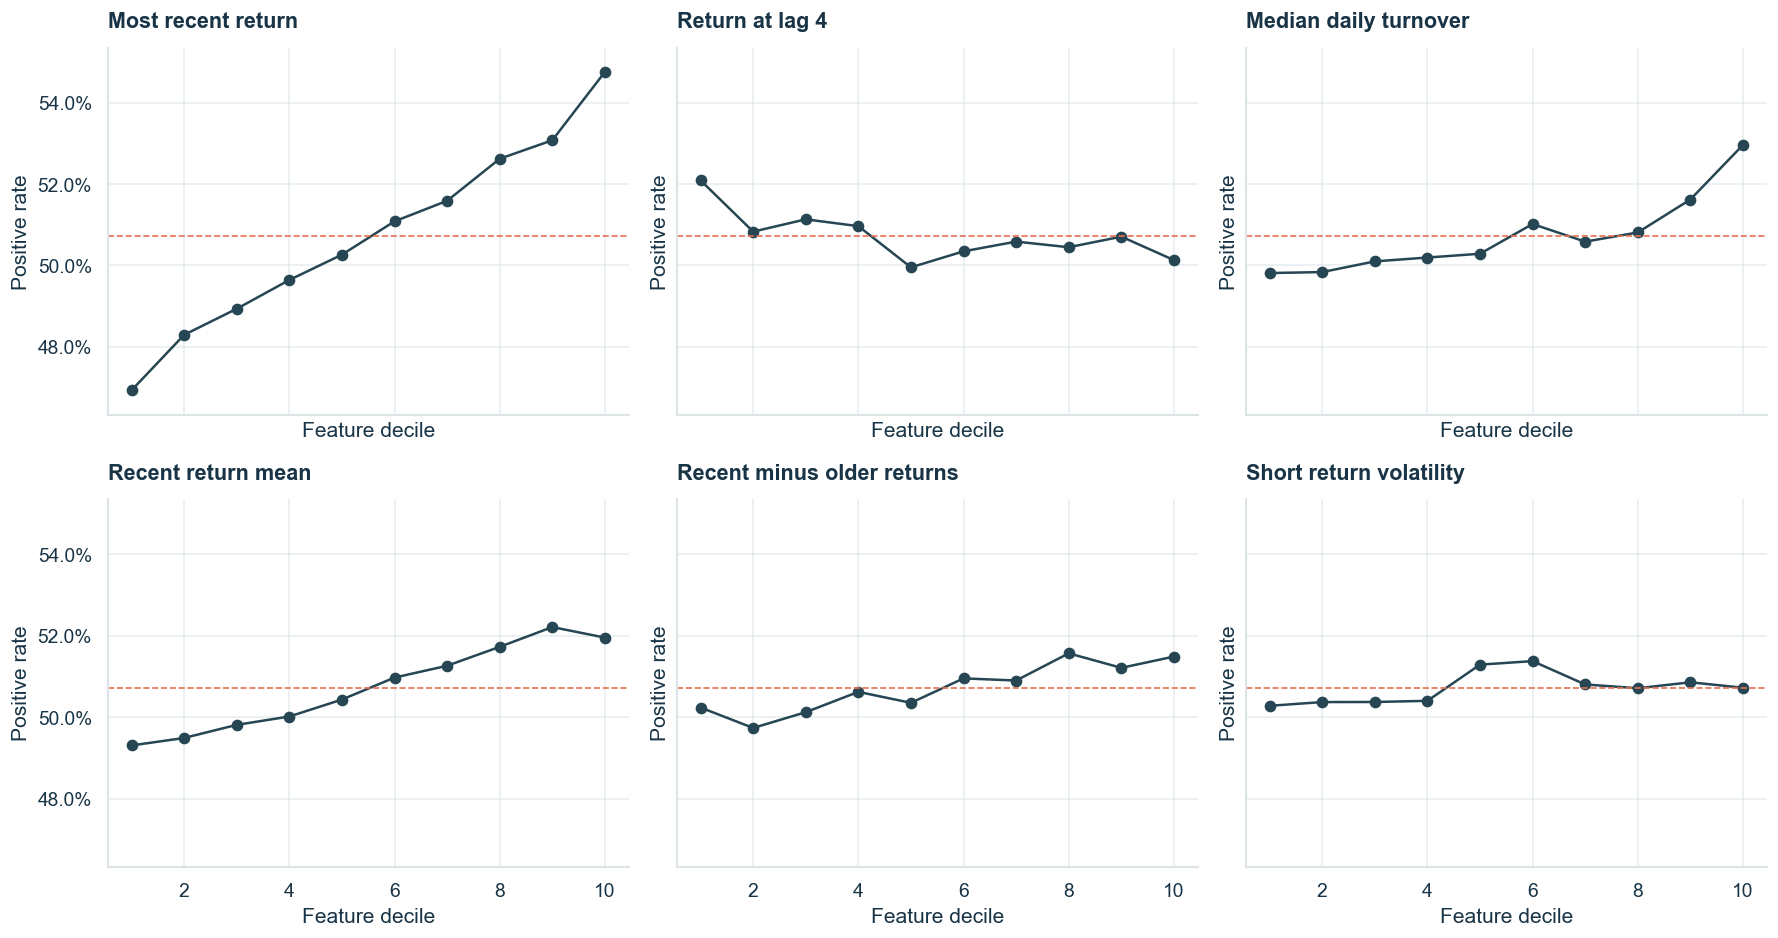

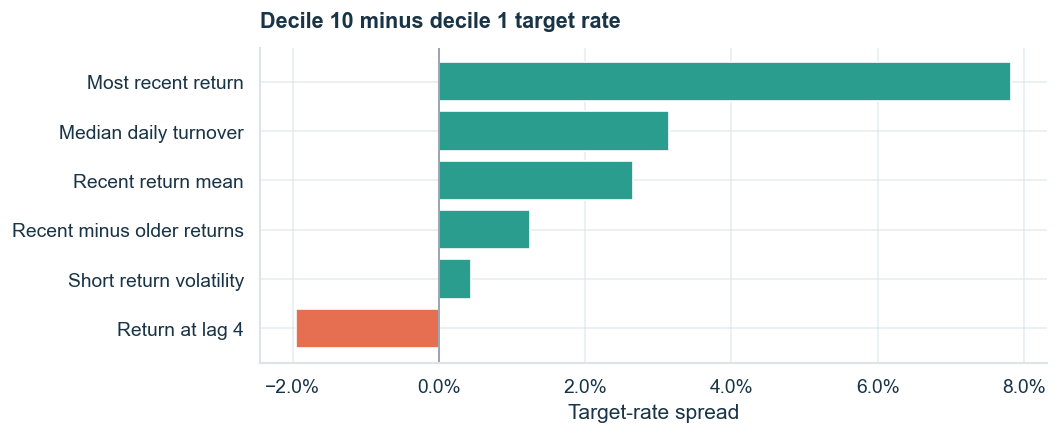

In [10]:
signal_frame = pd.concat(
    [train[["RET_1", "RET_4", "RET_7", "MEDIAN_DAILY_TURNOVER", "target_binarized"]], train_temporal],
    axis=1,
)
signal_features = [
    "RET_1", "RET_4", "MEDIAN_DAILY_TURNOVER",
    "recent_return_mean", "recent_minus_older", "short_return_volatility",
]
display_names = {
    "RET_1": "Most recent return",
    "RET_4": "Return at lag 4",
    "MEDIAN_DAILY_TURNOVER": "Median daily turnover",
    "recent_return_mean": "Recent return mean",
    "recent_minus_older": "Recent minus older returns",
    "short_return_volatility": "Short return volatility",
}

decile_rows = []
for feature in signal_features:
    valid = signal_frame[[feature, "target_binarized"]].dropna()
    decile = pd.qcut(valid[feature].rank(method="first"), q=10, labels=range(1, 11)).rename("decile")
    rates = valid.groupby(decile, observed=True)["target_binarized"].agg(["size", "mean"])
    rates = rates.rename(columns={"size": "rows", "mean": "positive rate"}).reset_index()
    rates["feature"] = feature
    decile_rows.append(rates)
decile_signal = pd.concat(decile_rows, ignore_index=True)

y_min = decile_signal["positive rate"].min() - 0.006
y_max = decile_signal["positive rate"].max() + 0.006
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, feature in zip(axes.flat, signal_features):
    subset = decile_signal[decile_signal["feature"] == feature]
    ax.plot(subset["decile"].astype(int), subset["positive rate"], color=COLORS["train"], marker="o")
    ax.axhline(overall_positive_rate, color=COLORS["accent"], linestyle="--", linewidth=1)
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    clean_axis(ax, title=display_names[feature], xlabel="Feature decile", ylabel="Positive rate")
plt.tight_layout()
plt.show()

separation = (
    decile_signal.pivot(index="feature", columns="decile", values="positive rate")
    .assign(decile_spread=lambda frame: frame[10] - frame[1])["decile_spread"]
    .sort_values()
)
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [COLORS["accent"] if value < 0 else COLORS["test"] for value in separation]
ax.barh([display_names[index] for index in separation.index], separation.values, color=colors)
ax.axvline(0, color=COLORS["muted"], linewidth=1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
clean_axis(ax, title="Decile 10 minus decile 1 target rate", xlabel="Target-rate spread", ylabel="")
plt.tight_layout()
plt.show()

> **What the plots show.** `RET_1` has the clearest and most monotone
> relationship with the target: the positive rate rises from about 47% in its
> lowest decile to about 55% in its highest. Turnover and the recent-return mean
> show smaller gradients. `RET_4` is non-monotone and its extreme-decile spread
> is negative.
>
> **Decision.** `RET_1` is the natural elementary benchmark. Other summaries
> remain hypotheses until they improve identical-fold OOF results.

## 5. Train/test distribution differences

For each numerical feature, the plot reports the Wasserstein distance between
train and test divided by their pooled interquartile range. This makes the
ranking comparable across variables with different units. It is a descriptive
effect-size ranking, not a hypothesis test or a universal drift threshold.

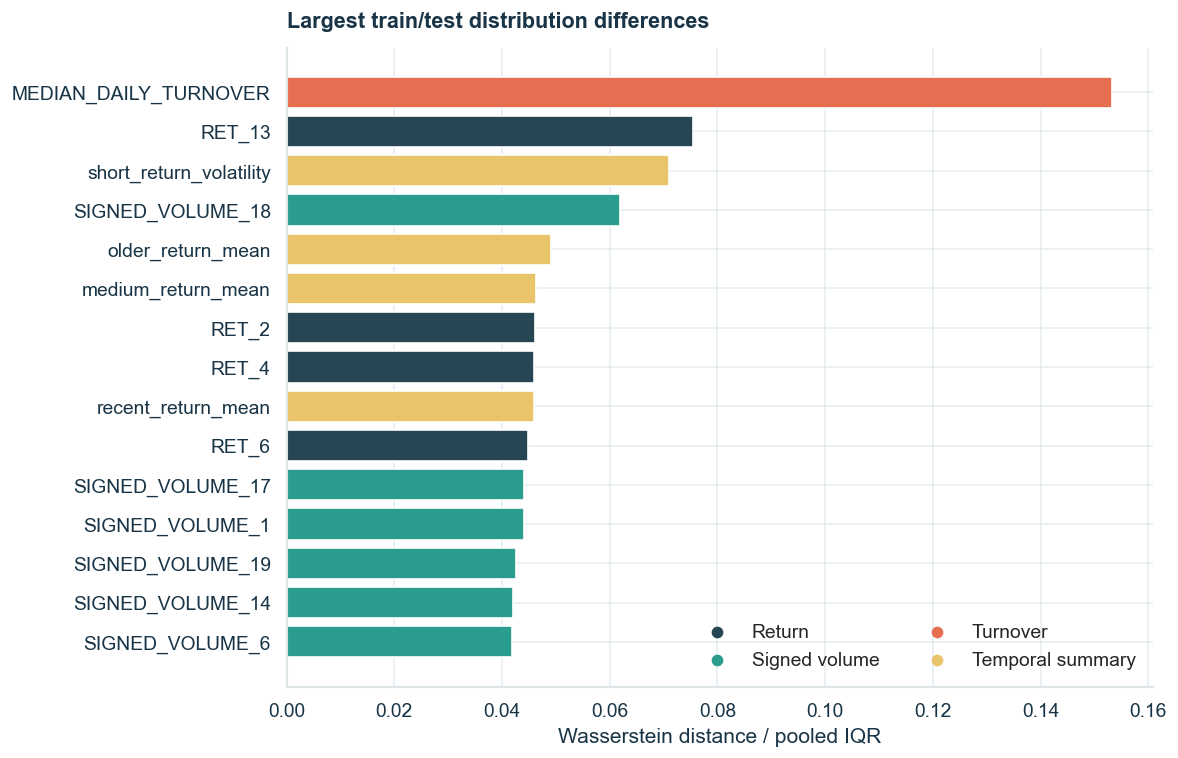

feature,family,normalised Wasserstein distance,missing-rate difference
MEDIAN_DAILY_TURNOVER,Turnover,0.153,0.22%
RET_13,Return,0.075,0.01%
short_return_volatility,Temporal summary,0.071,0.00%
SIGNED_VOLUME_18,Signed volume,0.062,0.15%
older_return_mean,Temporal summary,0.049,0.01%
medium_return_mean,Temporal summary,0.046,0.00%
RET_2,Return,0.046,0.00%
RET_4,Return,0.046,0.00%
recent_return_mean,Temporal summary,0.046,0.00%
RET_6,Return,0.045,0.00%


In [11]:
drift_train = pd.concat([X_train[RAW_FEATURES], train_temporal], axis=1)
drift_test = pd.concat([test[RAW_FEATURES], test_temporal], axis=1)

drift_rows = []
for feature in drift_train.columns:
    train_values = drift_train[feature].dropna().to_numpy()
    test_values = drift_test[feature].dropna().to_numpy()
    pooled = np.concatenate([train_values, test_values])
    scale = np.quantile(pooled, 0.75) - np.quantile(pooled, 0.25)
    scale = scale if scale > 0 else np.std(pooled)
    scale = scale if scale > 0 else 1.0
    family = "Temporal summary" if feature in train_temporal else (
        "Return" if feature.startswith("RET_") else (
            "Signed volume" if feature.startswith("SIGNED_VOLUME_") else "Turnover"
        )
    )
    drift_rows.append(
        {
            "feature": feature,
            "family": family,
            "normalised Wasserstein distance": wasserstein_distance(train_values, test_values) / scale,
            "normalised median shift": abs(np.median(test_values) - np.median(train_values)) / scale,
            "missing-rate difference": abs(drift_test[feature].isna().mean() - drift_train[feature].isna().mean()),
        }
    )
drift = pd.DataFrame(drift_rows).sort_values("normalised Wasserstein distance", ascending=False)
top_drift = drift.head(15).sort_values("normalised Wasserstein distance")
family_palette = {
    "Return": COLORS["train"],
    "Signed volume": COLORS["test"],
    "Turnover": COLORS["accent"],
    "Temporal summary": COLORS["gold"],
}

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(
    top_drift["feature"],
    top_drift["normalised Wasserstein distance"],
    color=top_drift["family"].map(family_palette),
)
for family, color in family_palette.items():
    ax.scatter([], [], color=color, label=family)
ax.legend(frameon=False, ncol=2, loc="lower right")
clean_axis(ax, title="Largest train/test distribution differences", xlabel="Wasserstein distance / pooled IQR", ylabel="")
plt.tight_layout()
plt.show()

(
    drift.head(12)[["feature", "family", "normalised Wasserstein distance", "missing-rate difference"]]
    .style.hide(axis="index")
    .format({"normalised Wasserstein distance": "{:.3f}", "missing-rate difference": "{:.2%}"})
    .set_caption("Features requiring the closest monitoring")
)

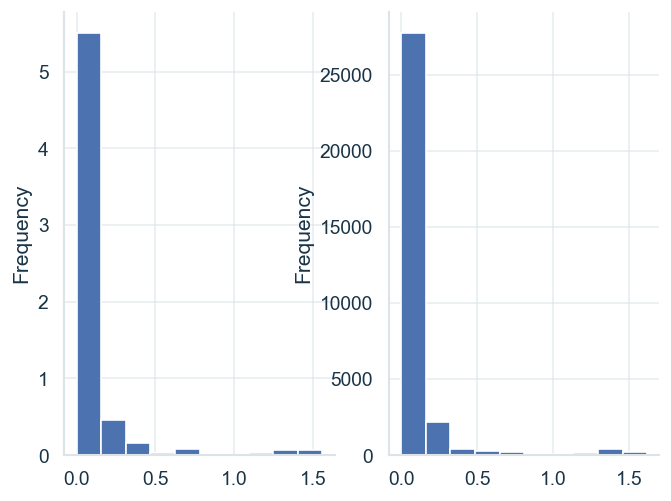

In [12]:
_, ax = plt.subplots(1, 2)
train["MEDIAN_DAILY_TURNOVER"].plot(kind="hist", bins=10, ax=ax[0], density=True)
test["MEDIAN_DAILY_TURNOVER"].plot(kind="hist", bins=10, ax=ax[1])
plt.show()

In [13]:
pd.DataFrame(
    {
        "train":train["MEDIAN_DAILY_TURNOVER"],
        "test":test["MEDIAN_DAILY_TURNOVER"]
    }
).agg(["mean", "median", "std", "skew"])

,train,test
mean,0.090944,0.085409
median,0.015935,0.014961
std,0.236489,0.233175
skew,4.322450,4.558295


> **What the plot shows.** `MEDIAN_DAILY_TURNOVER` has the largest normalised
> train/test difference (about 0.15), followed by `RET_13` and short-return
> volatility (about 0.07). Most remaining variables lie near 0.04 to 0.06.
> Test introduces no unseen allocation or group levels.
>
> **Decision.** Monitor turnover and compact volatility summaries explicitly.
> Do not transform distributions merely to make train and test look alike;
> require an improvement under grouped validation.

## 6. Consequences for the modelling notebooks

| Empirical result | Consequence |
|---|---|
| Coverage is unbalanced across dates and allocations | Validate on complete `TS` groups and shrink allocation effects. |
| Missingness is concentrated in the most recent signed-volume lag | Learn imputation and missingness features inside each fold. |
| Target prevalence varies strongly across dates | Do not use row-level independence for inference. |
| Returns have weak lag dependence; signed volume is persistent | Test compact lag summaries rather than a large feature expansion. |
| `RET_1` provides the clearest elementary signal | Use it as the primary transparent benchmark. |
| Turnover and short volatility differ most between train and test | Monitor them, but avoid automatic distribution correction. |

The next notebook compares models on identical date-grouped folds. A separate
simulation notebook will address the econometric treatment of standard errors
under panel dependence.